Livestock density is published one species at a time — cattle, buffalo, sheep, goats — but many analyses want a single grazing-pressure number. The **Tropical Livestock Unit (TLU)** provides that: each animal counts as a fraction of a 250 kg reference animal, so species can be weighted and summed into one comparable layer.

This notebook builds a TLU/km² map from [Gridded Livestock of the World v4](https://cgiar-climate-data-hub.github.io/catalog/glw4-2020/), streaming just the data it needs — nothing is downloaded ahead of time.

In [ ]:
import xarray as xr

## Open the data

GLW4 lives on object storage as a Zarr cube, so `xarray` opens it over HTTPS and only ever reads the chunks a computation touches. Inspecting the dataset shows one density variable per species, in head/km².

In [ ]:
ds = xr.open_zarr(
    "https://digital-atlas.s3.amazonaws.com/cdh/data/glw4-2020/glw4-2020.zarr"
)

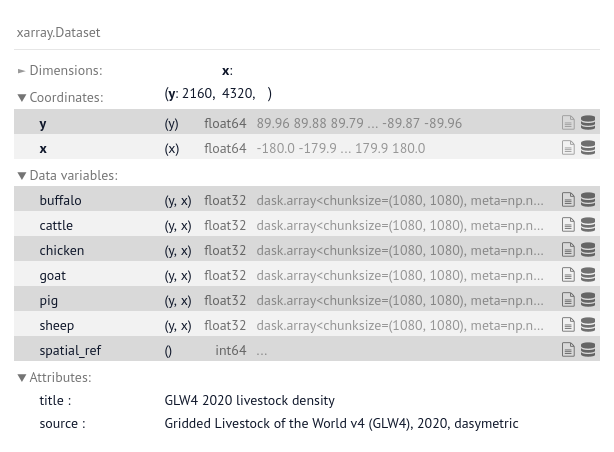

In [ ]:
ds

## Weight species into TLU

The FAO weights express each species as a fraction of a 250 kg tropical reference animal — a head of cattle counts as 0.7 TLU, a sheep or goat as 0.1. Multiplying each species layer by its weight and summing collapses the cube into a single TLU/km² surface.

In [ ]:
# Tropical Livestock Unit weights
# head/km² × weight = TLU/km².
TLU_RUMINANT = {"cattle": 0.7, "buffalo": 0.7, "sheep": 0.1, "goat": 0.1}

In [ ]:
layers = [w * ds[sp].fillna(0) for sp, w in TLU_RUMINANT.items()]
da = xr.concat(layers, dim="species").sum("species").rename("TLU")
da.attrs["units"] = "TLU/km2"

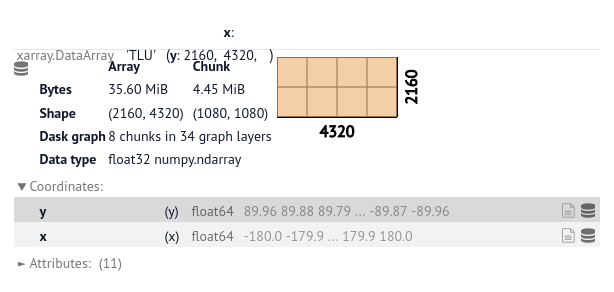

In [ ]:
da

## Subset and plot a region

Everything so far is lazy — no pixels have moved yet. Slicing before plotting means only the chunks inside the window are downloaded: here a roughly 8°×10° box over Kenya and northern Tanzania. `.plot()` gives a quick look; the same array is ready for zonal statistics or export.

In [ ]:
regional_tlu = da.sel(y=slice(5.0, -5.2), x=slice(34.0, 42.0))

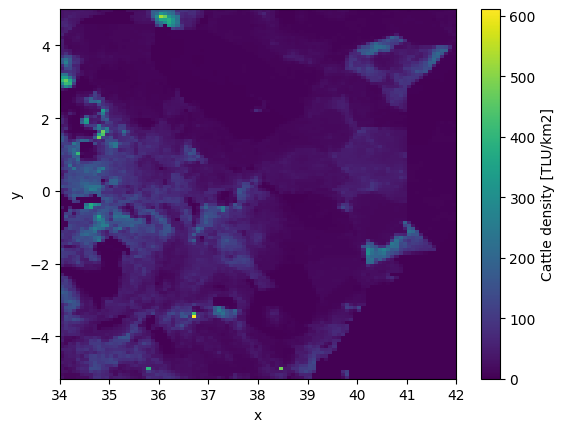

In [ ]:
regional_tlu.plot()

## Where to go next

Change the `slice` to your own region — the lazy reads mean any window costs only its own chunks. Per-species metadata, licensing, and the citation live on the [GLW4 record page](https://cgiar-climate-data-hub.github.io/catalog/glw4-2020/), and the weights dictionary is the place to add camels or other species if your context needs them.